# Упражнения к главе №1

## Упражнение 1.2

In [4]:
import os
import sys

module_dir = os.path.join(os.getcwd(), '..')
sys.path.insert(0, module_dir)


from thinkdsp import read_wave, decorate


filename = "155493__sankalp__electronic-tanpuar-19.wav"

wave = read_wave(filename)
wave.make_audio()


### Делаем сегмент

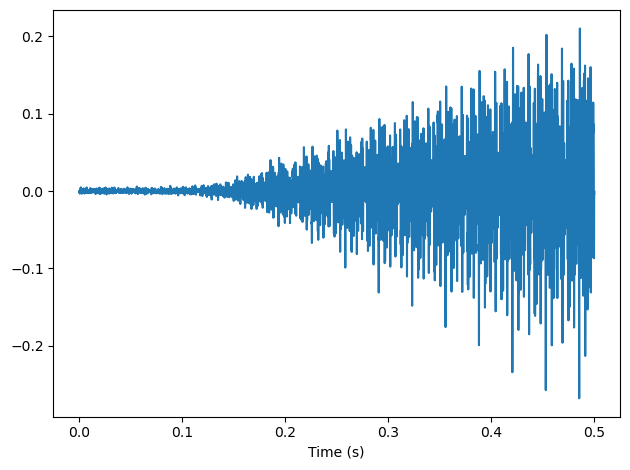

In [5]:
start = 0
duration = 0.5
segment = wave.segment(start, duration)
segment.plot()
decorate(xlabel="Time (s)")

### Делаем спектр

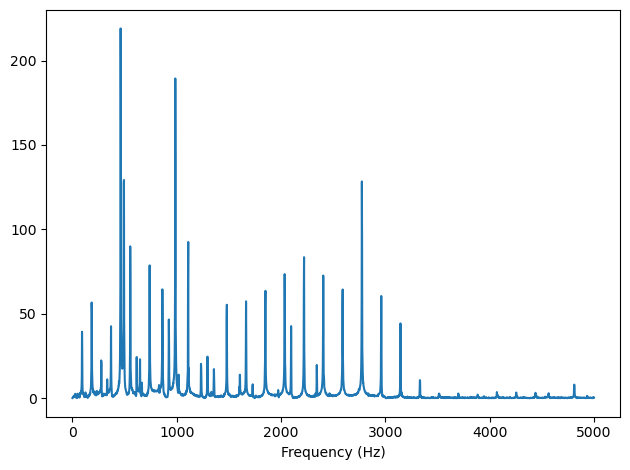

In [6]:
spectrum = segment.make_spectrum()
spectrum.plot(high=5000)
decorate(xlabel="Frequency (Hz)")

Как видно из графика спектра, основная частота - 100 Гц, тембр воспринимаего звука зависит от основной частоты, даже если она не доминирующая.

### Фильтрация гармоник

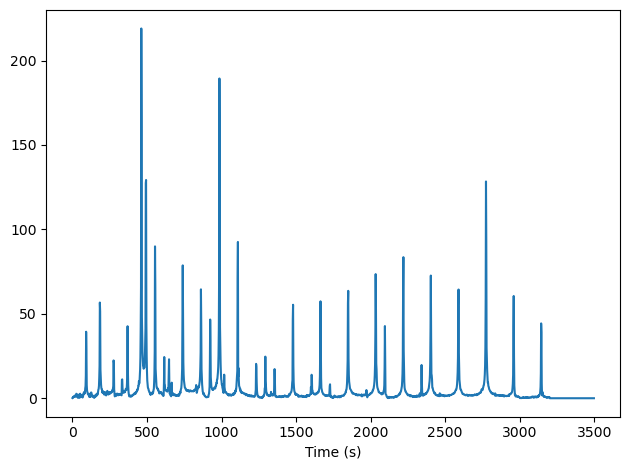

In [7]:
spectrum.low_pass(3200)
spectrum.plot(high=3500)
decorate(xlabel="Time (s)")

### Преобразуем в wav

In [8]:
filtered = spectrum.make_wave()
filtered.make_audio()

Что и требовалось доказать частоты выше 3200 никак не влияют на звук.

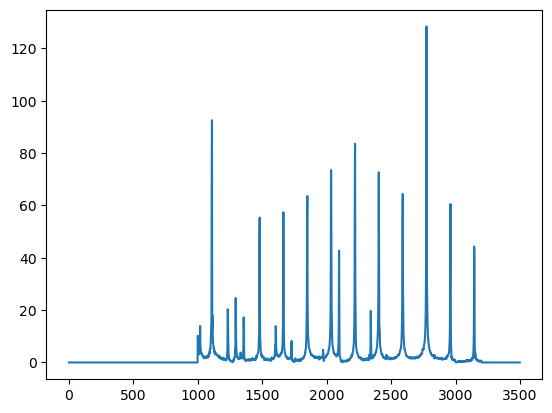

In [9]:
spectrum.high_pass(1000)
spectrum.plot(high=3500)

In [10]:
filtered = spectrum.make_wave()
filtered.make_audio()

Звук стал выше

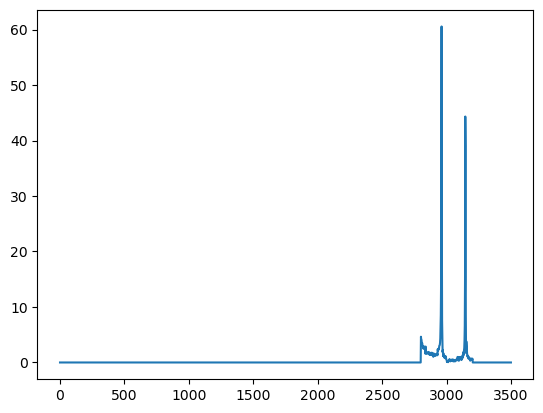

In [11]:
spectrum.band_stop(200, 2800)
spectrum.plot(high=3500)

In [12]:
filtered = spectrum.make_wave()
filtered.make_audio()

Звук совсем изменился до неузноваемости.

## Упражнение 1.3

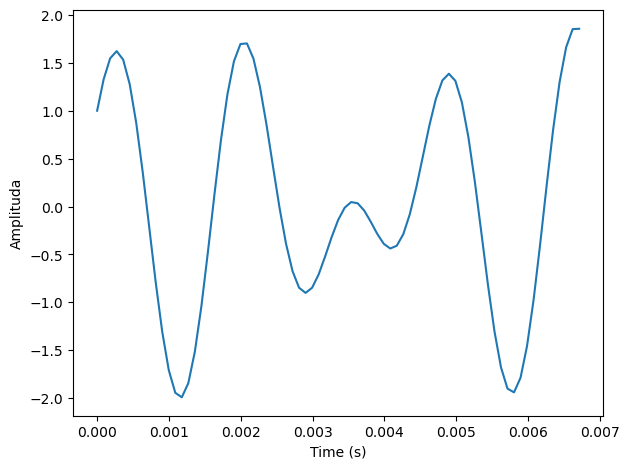

In [13]:
from thinkdsp import CosSignal, SinSignal

cos_signal = CosSignal(freq=440)
sin_signal = SinSignal(freq=644)

mix = cos_signal + sin_signal
mix.plot()
decorate(xlabel="Time (s)", ylabel="Amplituda")

### Вычислим спектр

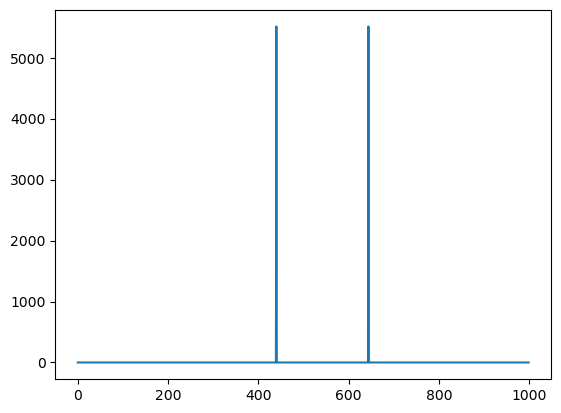

In [14]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot(high=1000)

### Добавим компоненту некратную исходным

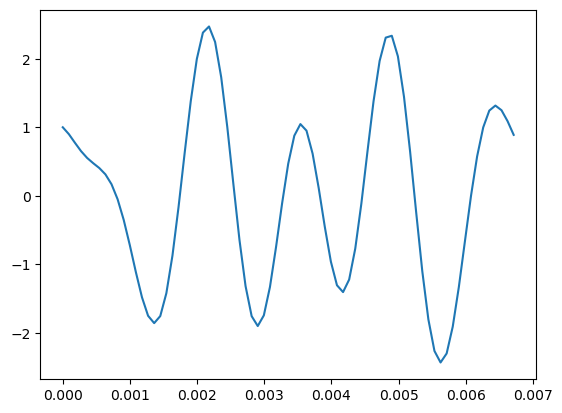

In [15]:
from thinkdsp import PI2

mix = mix + CosSignal(776, offset=PI2/4)
mix.plot()

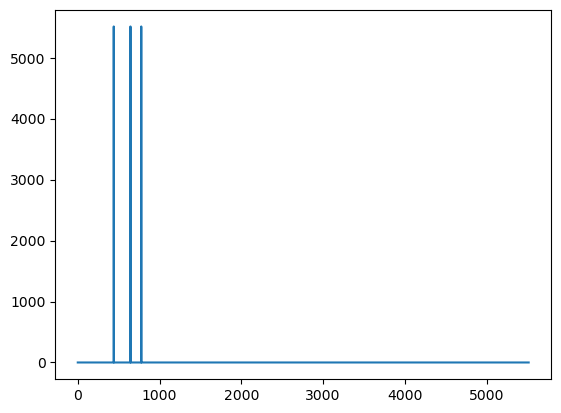

In [16]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot()

Что и требовалось доказать - в спектре появятся новые частоты и сигнал потеряет переодичность. Попробуем добавить крутную частоту к спектру.

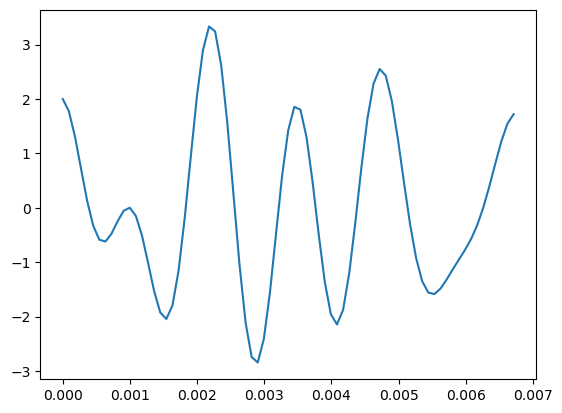

In [17]:
mix = mix + CosSignal(880)
mix.plot()

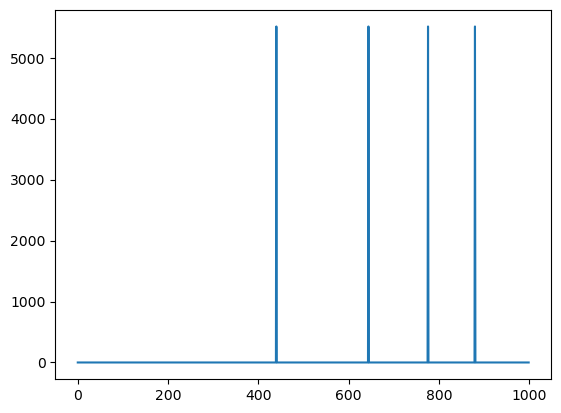

In [18]:
mix_wave = mix.make_wave()
spectrum = mix_wave.make_spectrum()
spectrum.plot(high=1000)

## Упрежнение 1.4

In [19]:
from thinkdsp import Wave


def stretch(wave: Wave, multiply_by: float) -> Wave:
    wave.ts *= multiply_by
    wave.framerate /= multiply_by
    return wave

wave.make_audio()

In [20]:
stretch(wave, multiply_by=0.25).make_audio()

In [21]:
stretch(wave, multiply_by=16).make_audio()